In [1]:
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
#import pyTMD

In [2]:
ds = xr.open_dataset("./pytmd_data/CATS2008_v2023/CATS2008_v2023.nc", chunks="auto")

In [3]:
ds

<xarray.Dataset> Size: 7GB
Dimensions:       (y: 4051, x: 3325, constituents: 10)
Coordinates:
  * y             (y) float32 16kB 4.5e+03 4.498e+03 ... -3.598e+03 -3.6e+03
  * x             (x) float32 13kB -3.05e+03 -3.048e+03 ... 3.596e+03 3.598e+03
  * constituents  (constituents) int8 10B 1 2 3 4 5 6 7 8 9 10
Data variables: (12/16)
    mapping       |S1 1B ...
    lat           (y, x) float32 54MB dask.array<chunksize=(4051, 3325), meta=np.ndarray>
    lon           (y, x) float32 54MB dask.array<chunksize=(4051, 3325), meta=np.ndarray>
    amplitude     (constituents) float64 80B dask.array<chunksize=(10,), meta=np.ndarray>
    phase         (constituents) float64 80B dask.array<chunksize=(10,), meta=np.ndarray>
    omega         (constituents) float32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    ...            ...
    UIm           (constituents, y, x) float64 1GB dask.array<chunksize=(4, 2259, 1855), meta=np.ndarray>
    VRe           (constituents, y, x) float64 1GB dask.array<chunksize=(4, 2259, 1855), meta=np.ndarray>
    VIm           (constituents, y, x) float64 1GB dask.array<chunksize=(4, 2259, 1855), meta=np.ndarray>
    wct           (y, x) int16 27MB dask.array<chunksize=(4051, 3325), meta=np.ndarray>
    mask          (y, x) int8 13MB dask.array<chunksize=(4051, 3325), meta=np.ndarray>
    flexure       (y, x) int8 13MB dask.array<chunksize=(4051, 3325), meta=np.ndarray>
Attributes:
    Conventions:        CF-1.7
    Description:        This is CATS2008, but resampled at 2 km resolution, a...
    creation_date:      2023-02-12
    NetCDF_conversion:  Chad A. Greene
    tmd_version:        3.0
    model_type:         ocean
    license:            Creative Commons Attribution 4.0 International License
    Title:              CATS2008_v2023
    Author:             Susan  L. Howard, Chad A. Greene, Laurie Padman, Svet...
    Data_citation:      Howard, S. L., Greene, C. A, Padman, L., Erofeeva, S....

In [4]:
amp = np.abs(ds.hRe + 1j*ds.hIm).where(ds.mask==1, np.nan)

In [5]:
amp

<xarray.DataArray (constituents: 10, y: 4051, x: 3325)> Size: 1GB
dask.array<where, shape=(10, 4051, 3325), dtype=float64, chunksize=(4, 2259, 1855), chunktype=numpy.ndarray>
Coordinates:
  * constituents  (constituents) int8 10B 1 2 3 4 5 6 7 8 9 10
  * y             (y) float32 16kB 4.5e+03 4.498e+03 ... -3.598e+03 -3.6e+03
  * x             (x) float32 13kB -3.05e+03 -3.048e+03 ... 3.596e+03 3.598e+03
Attributes:
    standard_name:  height_coefficient
    grid_mapping:   polar_stereographic
    units:          m

In [6]:
tide_range = 2 * amp.sum(dim="constituents")

In [7]:
tide_range

<xarray.DataArray (y: 4051, x: 3325)> Size: 108MB
dask.array<mul, shape=(4051, 3325), dtype=float64, chunksize=(2259, 1855), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float32 16kB 4.5e+03 4.498e+03 ... -3.598e+03 -3.6e+03
  * x        (x) float32 13kB -3.05e+03 -3.048e+03 ... 3.596e+03 3.598e+03
Attributes:
    standard_name:  height_coefficient
    grid_mapping:   polar_stereographic
    units:          m

In [8]:
tide_range_coarse = tide_range.coarsen(x=4, y=4, boundary='trim').mean()
tide_range_coarse

<xarray.DataArray (y: 1012, x: 831)> Size: 7MB
dask.array<mean_agg-aggregate, shape=(1012, 831), dtype=float64, chunksize=(564, 463), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float32 4kB 4.497e+03 4.489e+03 ... -3.583e+03 -3.591e+03
  * x        (x) float32 3kB -3.047e+03 -3.039e+03 ... 3.585e+03 3.593e+03
Attributes:
    standard_name:  height_coefficient
    grid_mapping:   polar_stereographic
    units:          m

In [9]:
tide_range_coarse.values

array([[0.57233528, 0.57567466, 0.57890064, ..., 0.75116062, 0.74888761,
        0.74671819],
       [0.57177074, 0.57499154, 0.57818119, ..., 0.75256397, 0.75031151,
        0.74794365],
       [0.57102844, 0.57435378, 0.5775936 , ..., 0.75381405, 0.75148942,
        0.7493903 ],
       ...,
       [1.30021913, 1.29458   , 1.28915568, ..., 0.78454271, 0.78687812,
        0.78908034],
       [1.29911174, 1.29285035, 1.28730259, ..., 0.79136695, 0.79356897,
        0.79562022],
       [1.2983504 , 1.29198897, 1.28613512, ..., 0.79821388, 0.80033434,
        0.80233489]], shape=(1012, 831))

In [10]:
print(tide_range_coarse)

<xarray.DataArray (y: 1012, x: 831)> Size: 7MB
dask.array<mean_agg-aggregate, shape=(1012, 831), dtype=float64, chunksize=(564, 463), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float32 4kB 4.497e+03 4.489e+03 ... -3.583e+03 -3.591e+03
  * x        (x) float32 3kB -3.047e+03 -3.039e+03 ... 3.585e+03 3.593e+03
Attributes:
    standard_name:  height_coefficient
    grid_mapping:   polar_stereographic
    units:          m


In [11]:
tide_range_coarse.nbytes

6727776

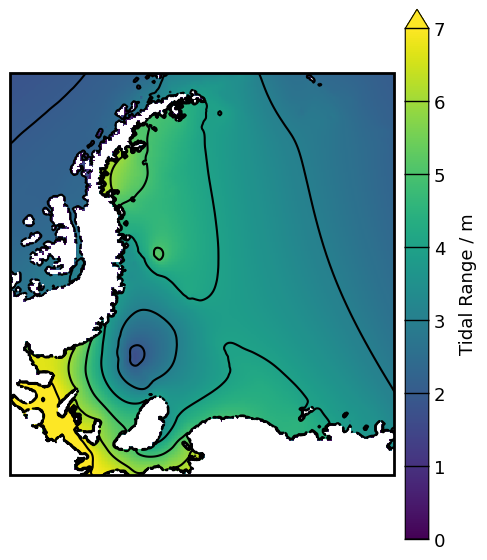

In [18]:
projection = ccrs.SouthPolarStereo()
#     central_longitude=0,
#     #central_latitude=-90,
#     true_scale_latitude=-71,
# )

fig, ax = plt.subplots(
    figsize=(2*3, 2*4),
    subplot_kw=dict(projection=projection),
)


tide_range_coarse = tide_range_coarse.where(tide_range_coarse.values != 0, np.nan)

im = ax.pcolormesh(
    tide_range_coarse["x"],
    tide_range_coarse["y"],
    tide_range_coarse,
    transform=projection,
    vmin=0,
    vmax=7,
    rasterized=True
)

ax.contour(
    tide_range_coarse["x"],
    tide_range_coarse["y"],
    tide_range_coarse,
    transform=projection,
    vmin=0,
    vmax=7,
    colors="k",
    levels= np.arange(2,8)
)


# # cartopy magic to add the 1000m isobath, taken from https://github.com/SciTools/cartopy/issues/1586
# from shapely.ops import unary_union
# bathym = cfeature.NaturalEarthFeature(name='bathymetry_J_1000', scale='10m', category='physical')
# bathym = unary_union(list(bathym.geometries()))
# from shapely.geometry import JOIN_STYLE
# delta = 0.0001 #Increase eps depending on your contour resolution
# bathym = bathym.buffer(delta, 1, join_style=JOIN_STYLE.mitre).buffer(-delta, 1, join_style=JOIN_STYLE.mitre)
# ax.add_geometries(bathym, facecolor='none', edgecolor='gray', linestyle='solid', linewidth=1, crs=ccrs.PlateCarree())
# ax.add_geometries(bathym, facecolor='none', edgecolor='gray', linestyle='solid', linewidth=1, crs=projection)
# # ax[1].add_geometries(bathym, facecolor='none', edgecolor='gray', linestyle='dashed', linewidth=1, crs=ccrs.PlateCarree())

# add moderate resolution cartopy coastlines
# ax.coastlines('50m', lw=6)

# Add colorbar and adjust size
# pad = distance from main plot axis
# extend = add extension triangles to upper and lower bounds
# options: neither, both, min, max
# shrink = percent size of colorbar
# aspect = lengthXwidth aspect of colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.025, extend='max',
    extendfrac=0.0375, shrink=0.86, aspect=22.5, drawedges=False)
# rasterized colorbar to remove lines
cbar.solids.set_rasterized(True)
# Add label to the colorbar
cbar.ax.set_ylabel(f'Tidal Range / m', labelpad=10, fontsize=13)
#cbar.ax.set_title('m', fontsize=13, va='bottom')
# ticks lines all the way across
cbar.ax.tick_params(which='both', width=1, length=18,
    labelsize=13, direction='in')

xlimits = [-300, 1800]
ylimits = [800, 3000]
# set x and y limits
ax.set_xlim(xlimits)
ax.set_ylim(ylimits)

# stronger linewidth on frame
ax.spines['geo'].set_linewidth(2.0)
ax.spines['geo'].set_capstyle('projecting')
# adjust subplot within figure
# fig.subplots_adjust(left=0.02,right=0.98,bottom=0.05,top=0.98)
# show the plot
plt.show()

# ax.gridlines()
# # Limit the map to -60 degrees latitude and below.
# ax.set_extent([-300, 1800, 800, 3000], projection)
# # ax.coastlines("50m", zorder=99, color="k")
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("peak-to-peak tidal range (m)")

fig.savefig("./tidal_range.pdf", bbox_inches="tight") #, dpi=200)
# plt.show()

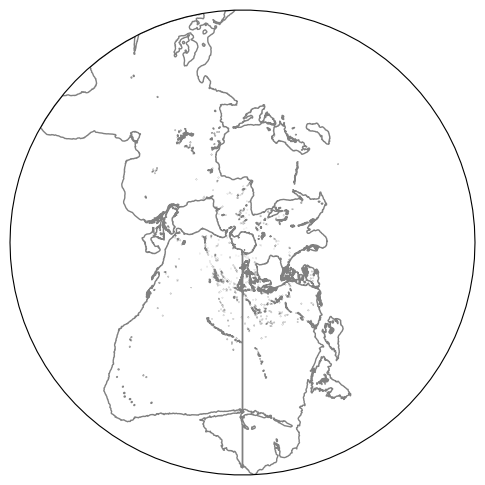

In [13]:
projection = ccrs.SouthPolarStereo()
#     central_longitude=0,
#     #central_latitude=-90,
#     true_scale_latitude=-71,
# )

fig, ax = plt.subplots(
    figsize=(2*3, 2*4),
    subplot_kw=dict(projection=projection),
)
# cartopy magic to add the 1000m isobath, taken from https://github.com/SciTools/cartopy/issues/1586
from shapely.ops import unary_union
bathym = cfeature.NaturalEarthFeature(name='bathymetry_J_1000', scale='10m', category='physical')
bathym = unary_union(list(bathym.geometries()))
from shapely.geometry import JOIN_STYLE
delta = 0.0001 #Increase eps depending on your contour resolution
bathym = bathym.buffer(delta, 1, join_style=JOIN_STYLE.mitre).buffer(-delta, 1, join_style=JOIN_STYLE.mitre)
ax.add_geometries(bathym, facecolor='none', edgecolor='gray', linestyle='solid', linewidth=1, crs=ccrs.PlateCarree())

In [14]:
# # Import the necessary libraries
# import cartopy.crs as ccrs
# import cartopy.feature as feat
# import matplotlib.pyplot as plt
# import matplotlib.path as mpath
# import shapely.geometry as sgeom
# import cartopy.mpl.patch as cpatch
# import matplotlib.patches as patches
# import matplotlib.ticker as mticker

In [15]:
# # Define the projection for a high-resolution South Polar Stereographic map
# high_res_proj = ccrs.SouthPolarStereo(central_longitude=-50)
# high_res_proj.threshold = 1e3

# # Create a new figure and subplot with the specified projection
# plt.figure(figsize=(6, 6))
# ax = plt.subplot(111, projection=high_res_proj)


# # Add the land feature to the map with specified appearance
# ax.add_feature(feat.NaturalEarthFeature('physical', 'land', '50m',
#                                         facecolor= "grey", #feat.COLORS['land'],
#                                         edgecolor='black',
#                                         linewidth=1.2))


# # Define the limits for the x-axis and y-axis of the map
# xlim = [-80, -20] # longitude
# ylim = [-60, -80] # latitude

# # Define a rectangular path for the map extent using matplotlib's Path object
# rect = mpath.Path([[xlim[0], ylim[0]],
#                    [xlim[1], ylim[0]],
#                    [xlim[1], ylim[1]],
#                    [xlim[0], ylim[1]],
#                    [xlim[0], ylim[0]],
#                    ])

# # Transform the rectangular path to the data coordinate system
# proj_to_data = ccrs.PlateCarree()._as_mpl_transform(ax) - ax.transData
# rect_in_target = proj_to_data.transform_path(rect)

# # Set the boundary of the map using the transformed rectangular path
# ax.set_boundary(rect_in_target)

# # Configure gridlines for the map
# gl = ax.gridlines()
#     # draw_labels=["top", "right", "x", "y"],
#     # rotate_labels=False, x_inline=False)

# # Draw latitude and longitude gridlines (and their labels)
# # only at the specified values
# lathelp = np.arange(-75, -60, 5)
# gl.ylocator = mticker.FixedLocator(lathelp)
# lonhelp = np.arange(-80, -10, 10)
# gl.xlocator = mticker.FixedLocator(lonhelp)

# # Rotate the longitude labels to be more readable
# # gl.xlabel_style = {'rotation': 30}

# # To make sure that all of the wanted map extent is visible in the figure,
# # (especially because the chosen map projections differs strongly
# # at the poles from the PlateCarree Projection)
# # this hack of adding a constant is needed and may need be adjusted,
# # dependent on your map extent and figure size
# ax.set_extent([xlim[0], xlim[1], ylim[0] + 4, ylim[1]])

# projection = ccrs.SouthPolarStereo()
# im = plt.pcolormesh(
#     tide_range_coarse["x"],
#     tide_range_coarse["y"],
#     tide_range_coarse,
#     transform=projection,
#     zorder=99
# )